In [1]:
# only for development
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
from src.experiments.ica import generate_artificial_data, sgld_ica_artificial, plot_amari_distances, plot_instability, plot_2d_pdfs
from src.experiments.ica import corrected_langevin_ica_artificial
from src.models import ICAModel

import numpy as np

In [ ]:
X, A = generate_artificial_data(N=1000, D=6)
model = ICAModel()

W_sgld, samples_sgld, iters_sgld = sgld_ica_artificial(X, model, steps=500000, batch_size=100)

In [5]:
samples_sgld.shape

(17964, 6, 6)

In [ ]:
# corrected langeving MCMC
W_corr, samples_corr = corrected_langevin_ica_artificial(X, W_init=W_sgld, model=model, steps=500000)

Step 0/50000 | Acceptance Rate: 1.0000
Step 10000/50000 | Acceptance Rate: 0.9023
Step 20000/50000 | Acceptance Rate: 0.9027
Step 30000/50000 | Acceptance Rate: 0.9015
Step 40000/50000 | Acceptance Rate: 0.9011
Final Acceptance Rate: 0.9008


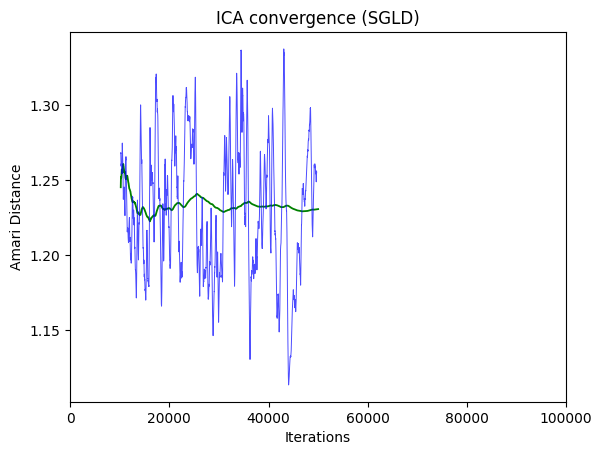

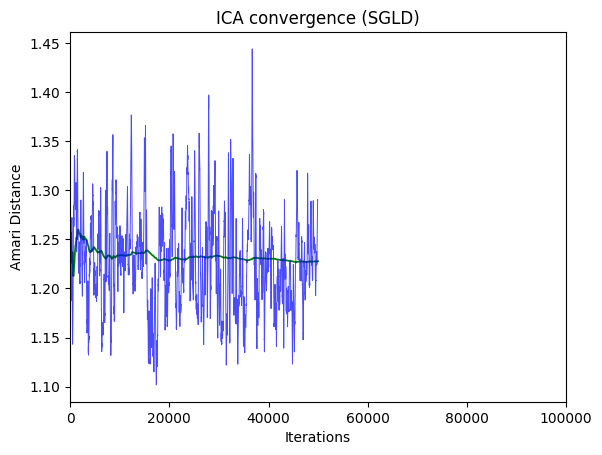

In [15]:
# amari distances
# SGLD
plot_amari_distances(samples_sgld, A, iters_sgld)


# Corrected Langeving
iters_corr = np.arange(len(samples_corr))
plot_amari_distances(samples_corr, A, iters_corr)

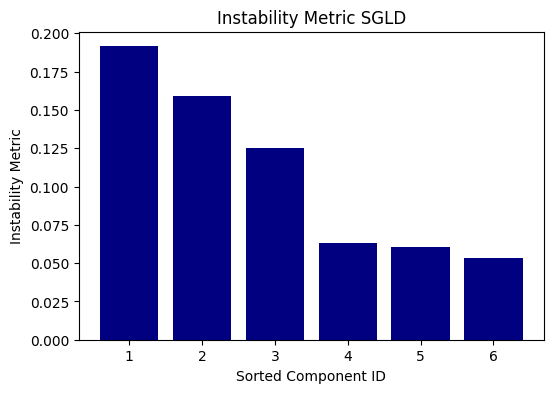

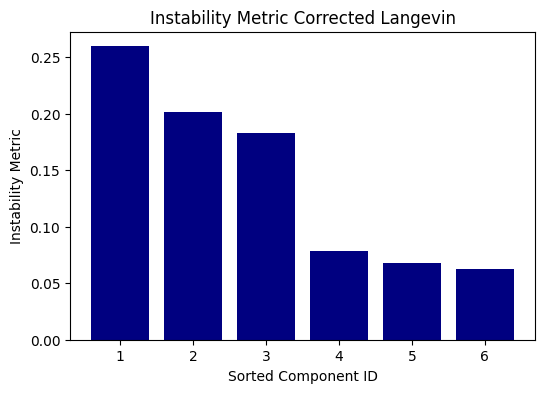

In [8]:
# instability
# SGLD
plot_instability(samples_sgld, X, experiment="Instability Metric SGLD")

# Corrected Langevin
plot_instability(samples_corr, X, experiment="Instability Metric Corrected Langevin")

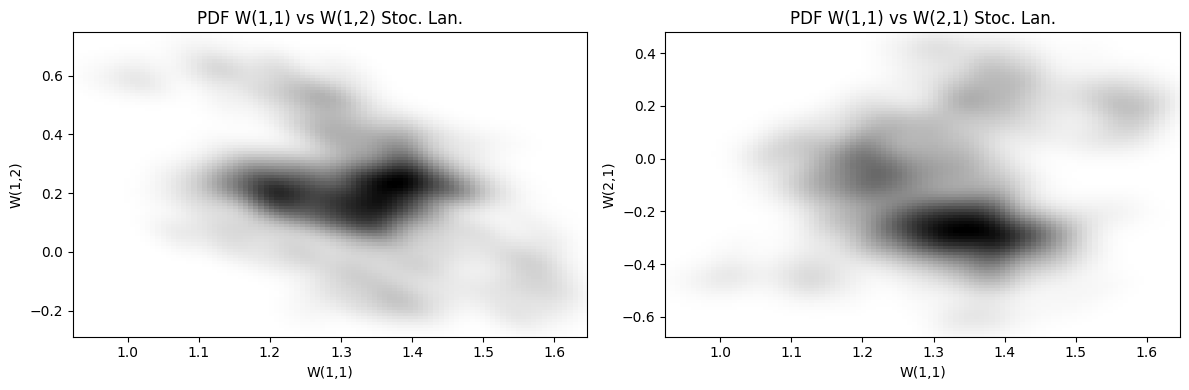

In [ ]:
# 2d pdfs
plot_2d_pdfs(samples_sgld, "Stoc. Lan.")

plot_2d_pdfs(samples_corr, "Corr. Lan.")
